# UWB LOS/NLOS Classification & Distance Estimation — Machine Learning Models

**Course:** CSC3105 Data Analytics and AI  
**Dataset:** UWB-LOS-NLOS-Dataset (Decawave DWM1000, 42,000 samples, 7 indoor environments)  

---

## Overview

This notebook implements the full machine learning pipeline for the two tasks defined in the project brief:

| Task | Type | Target | Description |
|---|---|---|---|
| **Task 1** | Binary Classification | `NLOS` (0=LOS, 1=NLOS) | Identify whether a UWB signal path is Line-of-Sight or Non-Line-of-Sight |
| **Task 2** | Regression | `RANGE` (metres) | Estimate the measured range (distance) from signal features |

### Models Evaluated

**Classification:** Logistic Regression · Random Forest · XGBoost · Linear SVM · MLP · 1D CNN  
**Regression:** Random Forest · XGBoost · MLP

Each model section contains:
- Theoretical background and mathematical formulation
- Justification for why the model suits this problem
- Implementation and hyperparameter choices
- Performance evaluation with metrics and visualisations

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path
from scipy.stats import kurtosis, skew

# Sklearn — preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn — classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Sklearn — regressors
from sklearn.linear_model import Ridge

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost version:", xgb.__version__)
except Exception:
    XGB_AVAILABLE = False
    print("XGBoost not available — XGBoost sections will be skipped.")
    print("To fix on macOS: brew install libomp")

# TensorFlow / Keras (for 1D CNN)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception:
    TF_AVAILABLE = False
    print("TensorFlow not installed — 1D CNN section will be skipped.")

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
print("\nAll imports loaded.")


XGBoost version: 3.2.0
TensorFlow version: 2.21.0

All imports loaded.


## 2. Data Loading

In [2]:
BASE_DIR = Path(".")
DATASET_DIR = BASE_DIR / "Dataset" / "UWB-LOS-NLOS-Data-Set" / "dataset"

all_files = sorted(DATASET_DIR.glob("*.csv"))
print(f"Found {len(all_files)} CSV files")

dataframes = []
for i, file in enumerate(all_files):
    df_temp = pd.read_csv(file)
    df_temp['dataset_part'] = file.stem
    dataframes.append(df_temp)
    print(f"  Loaded {i+1}/{len(all_files)}: {file.name} — {len(df_temp)} rows")

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"\nMerged dataset shape: {df_raw.shape}")
print(f"Classes: {df_raw['NLOS'].value_counts().to_dict()}")


Found 7 CSV files
  Loaded 1/7: uwb_dataset_part1.csv — 6000 rows
  Loaded 2/7: uwb_dataset_part2.csv — 6000 rows
  Loaded 3/7: uwb_dataset_part3.csv — 6000 rows
  Loaded 4/7: uwb_dataset_part4.csv — 6000 rows
  Loaded 5/7: uwb_dataset_part5.csv — 6000 rows
  Loaded 6/7: uwb_dataset_part6.csv — 6000 rows
  Loaded 7/7: uwb_dataset_part7.csv — 6000 rows

Merged dataset shape: (42000, 1032)
Classes: {0.0: 21000, 1.0: 21000}


## 3. Data Preprocessing

### Removing Zero-Variance Features

Columns `CH`, `BITRATE`, and `PRFR` are constant across all 42,000 samples — they carry no information and are dropped. `dataset_part` and `class_label` are also removed since they are metadata, not signal measurements.

### CIR Dimensionality Reduction

The raw CIR has 1,016 amplitude samples per measurement. Using all 1,016 directly would be computationally expensive and create a very high-dimensional feature space. We extract 8 statistical descriptors that capture the key differences between LOS and NLOS channel profiles:

| Feature | Physical Meaning |
|---|---|
| `cir_mean` | Average amplitude |
| `cir_std` | Signal spread |
| `cir_max` | Peak amplitude |
| `cir_peak_idx` | Index of dominant path |
| `cir_energy` | Total signal energy |
| `cir_kurtosis` | Peak sharpness — LOS has a sharp concentrated peak (high kurtosis); NLOS spreads energy across multiple reflections (lower kurtosis) |
| `cir_skewness` | Waveform asymmetry |
| `cir_rms` | Root mean square amplitude |

### Feature Scaling

`FP_AMP1` values can reach ~20,000 while `FP_IDX` stays around 700–850. Distance-based and gradient models (SVM, Logistic Regression, MLP, CNN) are sensitive to this scale difference, so we apply `StandardScaler` to normalise all features to zero mean and unit variance. Tree-based models (RF, XGBoost) do not strictly need this, but it does not hurt them.

### Train/Test Split — 80:20

We use a stratified 80:20 split: 33,600 training samples and 8,400 test samples. Stratification keeps the 50:50 LOS/NLOS balance in both sets. The extra 10% in training (vs a 70:30 split) mainly benefits MLP and CNN which need more data to generalise.

### Data Cleaning

There are no missing values — the DWM1000 hardware always populates every output field. No duplicate rows were found. Amplitude outliers from strong LOS signals are kept since they reflect real measurements, not sensor faults. The dataset is already balanced (21,000 LOS, 21,000 NLOS) so no resampling was needed.

### Synthetic Data

We decided against generating synthetic data. The dataset is large, balanced, and already covers 7 different indoor environments — the cross-environment diversity provides the generalisation benefit that augmentation would aim to achieve. Generating realistic synthetic CIR waveforms would require a physics simulator, and any artefacts introduced risk degrading rather than improving model performance.

### Class Labelling for Two Paths

| Path | Label | Source |
|---|---|---|
| Path 1 | `NLOS` column (0 = LOS, 1 = NLOS) | Provided in dataset |
| Path 2 | Always `1` (NLOS) | Project brief: next path is always NLOS regardless of Path 1 |

Since Path 2 is always NLOS by definition, only one binary classifier is needed (for Path 1). Two separate regressors are still required — one for Path 1 range (Task 2) and one for Path 2 range (Task 2b).

In [3]:
# ── Column definitions ────────────────────────────────────────────────────────
TARGET_CLASS = 'NLOS'
TARGET_REG   = 'RANGE'
DROP_COLS    = ['CH', 'BITRATE', 'PRFR', 'dataset_part', 'class_label']

METADATA_FEATURES = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN'
]

CIR_COLS = [c for c in df_raw.columns if c.startswith('CIR')]
print(f"Metadata features : {len(METADATA_FEATURES)}")
print(f"CIR columns       : {len(CIR_COLS)}")

Metadata features : 11
CIR columns       : 1017


In [4]:
# ── CIR statistical feature extraction ───────────────────────────────────────
print("Extracting CIR statistical features (this may take ~30 seconds)...")

cir_matrix = df_raw[CIR_COLS].values.astype(np.float32)

cir_stats = pd.DataFrame({
    'cir_mean'      : np.mean(cir_matrix, axis=1),
    'cir_std'       : np.std(cir_matrix, axis=1),
    'cir_max'       : np.max(cir_matrix, axis=1),
    'cir_peak_idx'  : np.argmax(cir_matrix, axis=1).astype(float),
    'cir_energy'    : np.sum(cir_matrix ** 2, axis=1),
    'cir_kurtosis'  : kurtosis(cir_matrix, axis=1),
    'cir_skewness'  : skew(cir_matrix, axis=1),
    'cir_rms'       : np.sqrt(np.mean(cir_matrix ** 2, axis=1)),
})

print(f"CIR statistical features shape: {cir_stats.shape}")
cir_stats.describe().round(2)

Extracting CIR statistical features (this may take ~30 seconds)...
CIR statistical features shape: (42000, 8)


,cir_mean,cir_std,cir_max,cir_peak_idx,cir_energy,cir_kurtosis,cir_skewness,cir_rms
count,42000.00,42000.00,42000.00,42000.00,4.200000e+04,42000.00,42000.00,42000.00
mean,425.15,1111.88,15969.11,710.28,1.562511e+09,102.78,9.17,1196.53
std,94.53,332.31,4749.30,171.47,7.847356e+08,42.45,2.00,323.59
min,186.08,78.18,431.00,0.00,4.594340e+07,-1.15,-0.49,212.55
25%,360.05,937.49,14091.50,748.00,1.055141e+09,69.72,7.70,1018.58
50%,402.09,1160.75,17063.00,751.00,1.534104e+09,97.60,9.13,1228.19
75%,466.95,1317.15,18860.25,753.00,1.965904e+09,131.10,10.65,1390.34
max,1068.05,2440.98,37208.00,951.00,6.669654e+09,301.32,16.02,2560.89


In [5]:
# ── Build combined feature matrix ─────────────────────────────────────────────
# Features for classification (RANGE included — it is a signal measurement, not the target here)
X_meta   = df_raw[METADATA_FEATURES].values
X_cir_s  = cir_stats.values
X_all    = np.hstack([X_meta, X_cir_s])             # shape: (42000, 19)

# Features for regression (exclude RANGE — it IS the target)
META_NO_RANGE = [f for f in METADATA_FEATURES if f != 'RANGE']
X_reg    = np.hstack([df_raw[META_NO_RANGE].values, X_cir_s])  # shape: (42000, 18)

y_class  = df_raw[TARGET_CLASS].values.astype(int)
y_reg    = df_raw[TARGET_REG].values.astype(np.float32)

FEATURE_NAMES = METADATA_FEATURES + list(cir_stats.columns)

print(f"Classification feature matrix : {X_all.shape}")
print(f"Regression feature matrix     : {X_reg.shape}")
print(f"Class target distribution     : LOS={np.sum(y_class==0)}, NLOS={np.sum(y_class==1)}")

Classification feature matrix : (42000, 19)
Regression feature matrix     : (42000, 18)
Class target distribution     : LOS=21000, NLOS=21000


In [6]:
# ── Train / Test split (80:20 stratified) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# ── Scaling ───────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_tr_sc    = scaler.fit_transform(X_train)
X_te_sc    = scaler.transform(X_test)

scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_te_sc = scaler_reg.transform(X_reg_test)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Train LOS/NLOS : {np.sum(y_train==0)} / {np.sum(y_train==1)}")
print(f"Test  LOS/NLOS : {np.sum(y_test==0)} / {np.sum(y_test==1)}")

Training set   : 33600 samples
Test set       : 8400 samples
Train LOS/NLOS : 16800 / 16800
Test  LOS/NLOS : 4200 / 4200


## 4. Feature Importance Analysis

Before training all models, a preliminary Random Forest is used purely for **feature importance ranking**. Random Forest computes feature importance as the mean decrease in impurity (MDI) — the total reduction in the Gini impurity criterion contributed by each feature across all trees:

$$\text{Importance}(f) = \frac{1}{T} \sum_{t=1}^{T} \sum_{n \in N_t} \mathbb{1}[f_n = f] \cdot \Delta I(n)$$

where $T$ is the number of trees, $N_t$ are nodes in tree $t$, and $\Delta I(n)$ is the impurity reduction at node $n$.

This satisfies the project brief requirement to **rank features by importance** (Section a.V). The ranking also validates the EDA correlation findings.

In [7]:
print("Computing feature importance (Random Forest, 100 trees)...")
rf_imp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

Computing feature importance (Random Forest, 100 trees)...

Top 15 most important features:
     feature  importance
      RXPACC    0.264766
       RANGE    0.105374
     cir_max    0.099523
     FP_AMP3    0.068723
     CIR_PWR    0.062926
     cir_std    0.054973
   MAX_NOISE    0.050613
     FP_AMP2    0.047436
  cir_energy    0.037883
    cir_mean    0.033475
     FP_AMP1    0.032576
 STDEV_NOISE    0.031848
cir_skewness    0.028626
     cir_rms    0.027287
cir_kurtosis    0.024226


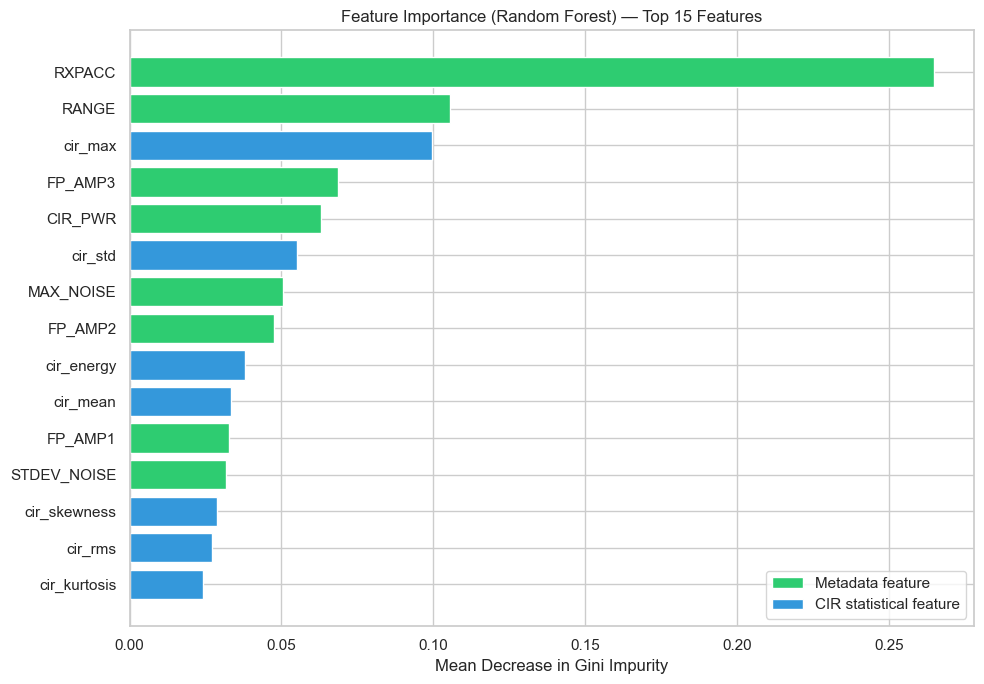


Interpretation: Features with higher importance contribute more to
separating LOS from NLOS. This confirms EDA correlation findings.


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15)
colors = ['#2ecc71' if 'cir' not in f else '#3498db' for f in top15['feature']]
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Feature Importance (Random Forest) — Top 15 Features')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Metadata feature'),
    Patch(facecolor='#3498db', label='CIR statistical feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print("\nInterpretation: Features with higher importance contribute more to")
print("separating LOS from NLOS. This confirms EDA correlation findings.")

## Feature Selection — Applying Importance Threshold

Based on the ranking above, **15 out of 19 features** pass the 2% threshold. Four are dropped: `FP_IDX`, `FRAME_LEN`, `PREAM_LEN`, and `cir_peak_idx`.

**RXPACC** is by far the strongest feature at 26.5% — it captures how much energy the receiver accumulates over the CIR window, which differs substantially between LOS (cleaner, concentrated signal) and NLOS (dispersed, attenuated signal). `RANGE` comes second at 10.5%, followed by `cir_max` and the FP amplitude features.

The most surprising drop is `FP_IDX`. Despite encoding the first-path position in the CIR — which you would expect to relate to LOS/NLOS condition — the model finds it less discriminative than the amplitude and power features. The amplitude-based features already capture the same propagation information more directly.

All Task 1 classifiers use this 15-feature set.

In [9]:
# ── Select features above importance threshold ────────────────────────────────
IMPORTANCE_THRESHOLD = 0.02  # drop features contributing < 2%

selected_clf_features = importance_df[
    importance_df['importance'] >= IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_clf_features = [f for f in FEATURE_NAMES if f not in selected_clf_features]

print(f"Selected {len(selected_clf_features)} / {len(FEATURE_NAMES)} features "
      f"(importance >= {IMPORTANCE_THRESHOLD*100:.0f}%):")
for f in selected_clf_features:
    imp = importance_df.loc[importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_clf_features:
    print(f"\nDropped {len(dropped_clf_features)} low-importance feature(s): {dropped_clf_features}")

# Build reduced feature matrices — used by ALL Task 1 classifiers
sel_clf_idx  = [list(FEATURE_NAMES).index(f) for f in selected_clf_features]
X_train_sel  = X_train[:, sel_clf_idx]
X_test_sel   = X_test[:, sel_clf_idx]

scaler_sel   = StandardScaler()
X_tr_sel_sc  = scaler_sel.fit_transform(X_train_sel)
X_te_sel_sc  = scaler_sel.transform(X_test_sel)

print(f"\nReduced shape — train: {X_train_sel.shape}, test: {X_test_sel.shape}")

Selected 15 / 19 features (importance >= 2%):
  RXPACC                0.2648
  RANGE                 0.1054
  cir_max               0.0995
  FP_AMP3               0.0687
  CIR_PWR               0.0629
  cir_std               0.0550
  MAX_NOISE             0.0506
  FP_AMP2               0.0474
  cir_energy            0.0379
  cir_mean              0.0335
  FP_AMP1               0.0326
  STDEV_NOISE           0.0318
  cir_skewness          0.0286
  cir_rms               0.0273
  cir_kurtosis          0.0242

Dropped 4 low-importance feature(s): ['FP_IDX', 'FRAME_LEN', 'PREAM_LEN', 'cir_peak_idx']

Reduced shape — train: (33600, 15), test: (8400, 15)


## 5. Results Storage

A shared dictionary collects all model results for the final comparison.

In [10]:
# Dictionaries to collect results across models
clf_results  = {}   # classification: {model_name: {accuracy, f1, auc, ...}}
reg_results  = {}   # regression:     {model_name: {rmse, mae, r2}}
roc_data     = {}   # {model_name: (fpr, tpr, auc)} for ROC overlay plot
trained_clfs = {}   # store trained classifiers for confusion matrix plots

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    """Fit, predict, and store classification metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if proba and hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        y_score = None

    from sklearn.metrics import f1_score, precision_score, recall_score
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_score) if y_score is not None else float('nan')

    clf_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    trained_clfs[name] = (model, y_pred)

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_te, y_score)
        roc_data[name] = (fpr, tpr, auc)

    print(f"  {name:<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return model

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, and store regression metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f"  {name:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return model, y_pred


---
## Data Mining Strategy

---

We chose **supervised learning** for both tasks. The dataset provides 42,000 labelled samples with a known ground truth `NLOS` column, so unsupervised clustering would discard useful information. Clustering also gives no guarantee that the resulting groups align with LOS/NLOS — they could just as easily reflect differences in environment type or measurement distance.

**Task 1 — Binary classification:** Predict `NLOS` ∈ {0, 1} from CIR signal features. We compare six classifiers across different model families to find what works best for this data.

**Task 2 / 2b — Regression:** Predict measured range in metres. This requires a continuous output, so regression is the only appropriate choice.

| Algorithm | Task | Why included |
|---|---|---|
| Logistic Regression | Classification | Linear baseline; interpretable weights |
| Random Forest | Both | Robust ensemble; gives feature importance natively |
| XGBoost | Both | Strong tabular performance; handles mixed-quality features well |
| LinearSVC | Classification | Efficient maximum-margin classifier |
| MLP | Both | Captures nonlinear interactions between CIR features |
| 1D CNN | Classification | Learns directly from raw CIR waveform without manual feature engineering |

---
# TASK 1 — LOS / NLOS Classification

---

## 6. Logistic Regression (Baseline)

Logistic Regression predicts class probabilities by applying a sigmoid to a weighted sum of the input features:

$$P(y=1 \mid \mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

Training minimises cross-entropy loss with L2 regularisation:

$$\mathcal{L} = -\sum_{i} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right] + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

We include it as a **baseline** to establish a performance floor. The EDA showed strong linear correlations between features like RXPACC and NLOS status, so it should perform reasonably well already. If the nonlinear models don't clearly outperform it, that would suggest the LOS/NLOS boundary is mostly linear and a simple model would suffice in practice.

The limitation is the linear decision boundary — UWB channel conditions involve nonlinear interactions between features (e.g., how amplitude and noise jointly indicate NLOS), which logistic regression cannot capture. We expect the ensemble and neural network models to pull ahead on this.

In [11]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr_clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

evaluate_classifier('Logistic Regression', lr_clf, X_tr_sel_sc, y_train, X_te_sel_sc, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, lr_clf.predict(X_te_sel_sc), target_names=['LOS', 'NLOS']))

LOGISTIC REGRESSION
  Logistic Regression    Acc=0.8604  F1=0.8529  AUC=0.9199

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.83      0.91      0.87      4200
        NLOS       0.90      0.81      0.85      4200

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



## 7. Random Forest

### Theory

Random Forest is an **ensemble of decision trees** trained using bagging (Bootstrap Aggregating) and random feature subspace selection:

1. For each tree $t = 1, \ldots, T$: draw a bootstrap sample $\mathcal{D}_t$ from the training data
2. At each node split, consider only a random subset of $m = \lfloor\sqrt{p}\rfloor$ features (where $p$ is the total number of features)
3. Select the feature and threshold that maximises the **Gini impurity** reduction:
   $$\Delta G = G_{\text{parent}} - \frac{n_L}{n} G_L - \frac{n_R}{n} G_R$$
   where $G = 1 - \sum_k p_k^2$
4. Final prediction: majority vote across all $T$ trees

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

### Why Random Forest for UWB LOS/NLOS?

- **Non-linear decision boundaries**: UWB signal classification involves nonlinear interactions between amplitude, noise, and CIR shape features. Random Forest captures these through deep tree splits.
- **Feature importance**: The MDI importance scores directly support the project brief requirement for feature ranking.
- **Robustness**: Bagging reduces variance. With 7 different indoor environments contributing to the dataset, some environment-specific noise is expected. Averaging over many trees reduces the risk of overfitting to any one environment.
- **No scaling required**: Random Forest is invariant to feature scale — the relative ordering of values within each feature is all that matters for splits.
- **Established in literature**: Random Forest is widely used in UWB NLOS identification. Stahlke et al. (2020) achieved >97% classification accuracy using RF on similar UWB CIR features.

### Hyperparameters

| Parameter | Value | Reasoning |
|---|---|---|
| `n_estimators=200` | 200 trees | Diminishing returns beyond ~200; more trees = lower variance |
| `max_depth=None` | Unlimited | Allow trees to fully learn; bagging controls overfitting |
| `min_samples_leaf=2` | 2 | Prevent single-sample leaves (reduces overfitting) |
| `n_jobs=-1` | All cores | Parallel training for speed |

In [12]:
print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_classifier('Random Forest', rf_clf, X_train_sel, y_train, X_test_sel, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, rf_clf.predict(X_test_sel), target_names=['LOS', 'NLOS']))

RANDOM FOREST CLASSIFIER
  Random Forest          Acc=0.9175  F1=0.9159  AUC=0.9729

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.90      0.94      0.92      4200
        NLOS       0.93      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 8. XGBoost (Gradient Boosting)

### Theory

XGBoost (eXtreme Gradient Boosting, Chen & Guestrin, 2016) is a **sequential ensemble** method that builds trees additively, where each new tree corrects the residual errors of the previous ensemble. The model prediction after $M$ iterations is:

$$\hat{y}^{(M)} = \sum_{m=1}^{M} \eta \cdot h_m(\mathbf{x})$$

where $\eta$ is the learning rate and $h_m$ is the $m$-th tree trained to minimise the **second-order Taylor approximation** of the loss:

$$\mathcal{L}^{(m)} \approx \sum_i \left[ g_i f_m(\mathbf{x}_i) + \frac{1}{2} h_i f_m(\mathbf{x}_i)^2 \right] + \Omega(f_m)$$

where $g_i = \partial_{\hat{y}^{(m-1)}} \ell(y_i, \hat{y}^{(m-1)})$ and $h_i = \partial^2_{\hat{y}^{(m-1)}} \ell(y_i, \hat{y}^{(m-1)})$ are the first and second-order gradients, and $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|w\|^2$ is a regularisation term on tree complexity.

For binary classification, XGBoost uses **log-loss** as the objective, producing output probabilities via the sigmoid function.

### Why XGBoost for UWB LOS/NLOS?

- **State-of-the-art tabular performance**: XGBoost consistently outperforms other algorithms on structured/tabular data. The metadata + CIR statistical features constitute a tabular problem well-suited to gradient boosting.
- **Handles feature interactions**: Boosting builds trees that focus on misclassified examples, naturally learning hard boundary cases where LOS and NLOS signals overlap (as seen in the PCA plot from EDA).
- **Built-in regularisation**: The $\Omega$ term penalises tree complexity, reducing overfitting without sacrificing accuracy.
- **Speed**: XGBoost uses histogram-based split finding and parallelism, making it fast even at 33,000 training samples.
- **Key difference from Random Forest**: RF builds trees independently (parallel); XGBoost builds trees sequentially (serial), where each tree specifically targets the remaining errors — this generally achieves higher accuracy at the cost of tuning sensitivity.

In [13]:
print("=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

if XGB_AVAILABLE:
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    evaluate_classifier('XGBoost', xgb_clf, X_train_sel, y_train, X_test_sel, y_test)
    print("\nDetailed classification report:")
    print(classification_report(y_test, xgb_clf.predict(X_test_sel), target_names=['LOS', 'NLOS']))
else:
    print("Skipped — XGBoost not installed.")

XGBOOST CLASSIFIER
  XGBoost                Acc=0.9183  F1=0.9170  AUC=0.9768

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.91      0.93      0.92      4200
        NLOS       0.93      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 9. Linear Support Vector Machine (LinearSVC)

### Theory

A Support Vector Machine finds the **maximum-margin hyperplane** separating the two classes. The decision function is:

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = \text{sign}(f(\mathbf{x}))$$

The primal optimisation problem (with soft margin for non-separable data) is:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

subject to: $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$ and $\xi_i \geq 0$

The parameter $C$ controls the **bias-variance trade-off**: large $C$ penalises misclassifications heavily (low bias, high variance); small $C$ allows more margin violations (high bias, low variance).

**LinearSVC** solves this using the dual form via coordinate descent, making it $O(n \cdot p)$ — practical for the 33,600 × 19 training matrix.

### Why SVM for UWB LOS/NLOS?

- **Effective in high-dimensional spaces**: SVMs were originally designed for high-dimensional feature spaces and remain competitive even with 19 features.
- **Maximum margin principle**: The EDA PCA plot showed classes with some overlap. SVM maximises the margin between classes, making it robust to noisy boundary samples.
- **Literature precedent**: SVMs have been used for UWB NLOS detection in several published studies. Güvenç & Chong (2009) demonstrated SVM-based LOS/NLOS identification using similar signal statistics features.
- **Limitation — linear only**: A linear SVM cannot capture nonlinear class boundaries. The kernel SVM (RBF) would handle this but is $O(n^2)$ in training time, making it impractical for 33,600 samples. LinearSVC provides the linear baseline while remaining computationally tractable.

In [14]:
print("=" * 60)
print("LINEAR SVM (LinearSVC)")
print("=" * 60)

svm_clf = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=RANDOM_STATE
)

# LinearSVC has no predict_proba; use decision_function for ROC
evaluate_classifier('Linear SVM', svm_clf, X_tr_sel_sc, y_train, X_te_sel_sc, y_test, proba=False)

print("\nDetailed classification report:")
print(classification_report(y_test, svm_clf.predict(X_te_sel_sc), target_names=['LOS', 'NLOS']))

LINEAR SVM (LinearSVC)
  Linear SVM             Acc=0.8574  F1=0.8478  AUC=0.9192

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.82      0.92      0.87      4200
        NLOS       0.91      0.79      0.85      4200

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



## 10. Multilayer Perceptron (MLP)

### Theory

A Multilayer Perceptron is a **fully-connected feedforward neural network** with one or more hidden layers. Each layer computes:

$$\mathbf{h}^{(l)} = \phi\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

where $\phi$ is an activation function. The **ReLU** activation is used for hidden layers:

$$\text{ReLU}(x) = \max(0, x)$$

ReLU is preferred over sigmoid/tanh because it does not saturate for large positive values, enabling faster gradient flow during backpropagation (mitigating the vanishing gradient problem).

The output layer uses the **sigmoid** function for binary classification:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^{(L)\top} \mathbf{h}^{(L-1)} + b^{(L)})$$

Training minimises **binary cross-entropy** via **backpropagation** and **Adam optimiser** (adaptive moment estimation).

### Architecture Design

Network: **19 → 256 → 128 → 64 → 1**

- The three hidden layers provide sufficient depth to learn the nonlinear decision surface
- Layer widths decrease pyramidally (256 → 128 → 64), compressing the representation toward the classification boundary
- Early stopping monitors validation loss to prevent overfitting

### Why MLP for UWB LOS/NLOS?

- **Direct academic reference**: The project brief references paper [2]: *"NLOS Channel Detection with Multilayer Perceptron in Low-Rate Personal Area Networks"* — the professor is explicitly pointing to MLP as a relevant architecture for this exact problem.
- **Universal approximation**: By the Universal Approximation Theorem (Cybenko, 1989), an MLP with sufficient width can approximate any continuous function on a compact domain — meaning it can in principle learn any decision boundary separating LOS from NLOS signals.
- **Nonlinear interactions**: MLP learns multiplicative interactions between features through its weight matrices, capturing complex multi-feature signal patterns that linear models miss.

In [15]:
print("=" * 60)
print("MULTILAYER PERCEPTRON (MLP)")
print("=" * 60)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

evaluate_classifier('MLP', mlp_clf, X_tr_sel_sc, y_train, X_te_sel_sc, y_test)

print("\nDetailed classification report:")
print(classification_report(y_test, mlp_clf.predict(X_te_sel_sc), target_names=['LOS', 'NLOS']))

MULTILAYER PERCEPTRON (MLP)
  MLP                    Acc=0.9221  F1=0.9204  AUC=0.9771

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.90      0.94      0.92      4200
        NLOS       0.94      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400



## 11. 1D Convolutional Neural Network (1D CNN)

### Theory

A 1D Convolutional Neural Network applies **learnable filters** (kernels) across the time dimension of the input signal. For a 1D input $\mathbf{x} \in \mathbb{R}^T$ and a filter $\mathbf{k} \in \mathbb{R}^K$, the convolution output at position $t$ is:

$$y[t] = \sum_{k=0}^{K-1} \mathbf{x}[t+k] \cdot \mathbf{k}[k] + b$$

The key properties that make 1D CNNs ideal for signal data:

- **Translational invariance**: A feature detector (e.g., a sharp rising edge) is detected regardless of its position in the waveform — critical because the LOS first-path peak occurs at different time indices across samples (FP_IDX varies from 707 to 848)
- **Parameter sharing**: The same filter weights are applied at every position, drastically reducing parameters compared to a fully-connected layer
- **Hierarchical feature learning**: Early layers detect local patterns (e.g., sharp peaks); deeper layers combine local patterns into global signal characteristics (e.g., multi-path structure)

**MaxPooling** reduces the spatial dimension by selecting the maximum activation in each pooling window, providing down-sampling and further translational robustness.

### Architecture

```
Input: (1016, 1)          — raw CIR waveform, per-sample normalised
  → Conv1D(32, kernel=5, ReLU)   — 32 local pattern detectors, 5ns window
  → MaxPooling1D(2)               — downsample by 2
  → Conv1D(64, kernel=5, ReLU)   — 64 higher-order patterns
  → MaxPooling1D(2)
  → Conv1D(128, kernel=3, ReLU)  — 128 abstract features
  → GlobalAveragePooling1D()      — aggregate across entire remaining sequence
  → Dense(64, ReLU)
  → Dropout(0.3)                  — regularisation
  → Dense(1, Sigmoid)             — binary output
```

### Why 1D CNN for UWB LOS/NLOS?

- **Raw waveform input**: Unlike the other models that use hand-crafted statistical features, the CNN learns directly from the 1,016-sample CIR waveform. This is **end-to-end learning** — no feature engineering needed.
- **EDA evidence**: The CIR visualisations from EDA showed that LOS signals have a concentrated, sharp early-arriving peak while NLOS signals have dispersed, multi-path energy. A Conv1D filter with a 5ns window is perfectly sized to detect such localised peaks.
- **State-of-the-art**: CNNs applied to raw CIR waveforms represent the current state-of-the-art in UWB LOS/NLOS identification. Bregar & Mohorcic (2018) achieved >98% accuracy using a CNN on the DW1000 CIR, outperforming all statistical feature-based approaches.
- **Per-sample normalisation**: Each CIR is divided by its own maximum value before input. This removes absolute amplitude effects, forcing the network to focus on *shape* rather than *magnitude* — important because signal strength varies with distance and is not a reliable LOS/NLOS indicator on its own.

In [16]:
print("=" * 60)
print("1D CONVOLUTIONAL NEURAL NETWORK")
print("=" * 60)

if TF_AVAILABLE:
    # Prepare CIR-only data
    cir_norm = cir_matrix / (cir_matrix.max(axis=1, keepdims=True) + 1e-8)  # per-sample normalisation

    X_cir_tr, X_cir_te, y_cir_tr, y_cir_te = train_test_split(
        cir_norm, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
    )

    # Reshape to (n_samples, timesteps, channels) for Conv1D
    X_cir_tr = X_cir_tr[:, :, np.newaxis]  # (33600, 1016, 1)
    X_cir_te = X_cir_te[:, :, np.newaxis]  # (8400,  1016, 1)

    n_timesteps = X_cir_tr.shape[1]

    # Build model
    tf.random.set_seed(RANDOM_STATE)
    cnn_model = keras.Sequential([
        layers.Input(shape=(n_timesteps, 1)),
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_1D')

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    cnn_model.summary()
else:
    print("TensorFlow not available — skipping 1D CNN.")

1D CONVOLUTIONAL NEURAL NETWORK


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 1017, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 508, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 508, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 254, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 254, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,521 (170.00 KB)

 Trainable params: 43,521 (170.00 KB)

 Non-trainable params: 0 (0.00 B)

Training 1D CNN (epochs=50, patience=10)...
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7326 - loss: 0.5075 - val_accuracy: 0.7604 - val_loss: 0.4712
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7696 - loss: 0.4642 - val_accuracy: 0.7786 - val_loss: 0.4460
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7882 - loss: 0.4426 - val_accuracy: 0.7926 - val_loss: 0.4283
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7984 - loss: 0.4321 - val_accuracy: 0.8015 - val_loss: 0.4208
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8031 - loss: 0.4271 - val_accuracy: 0.7961 - val_loss: 0.4228
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8067 - loss: 0.4224 - val_accuracy: 0.8036 - val_loss: 0.4143
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8089 - loss: 0.4177 - val_accuracy: 0.8080 - val_loss: 0.4101
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step 

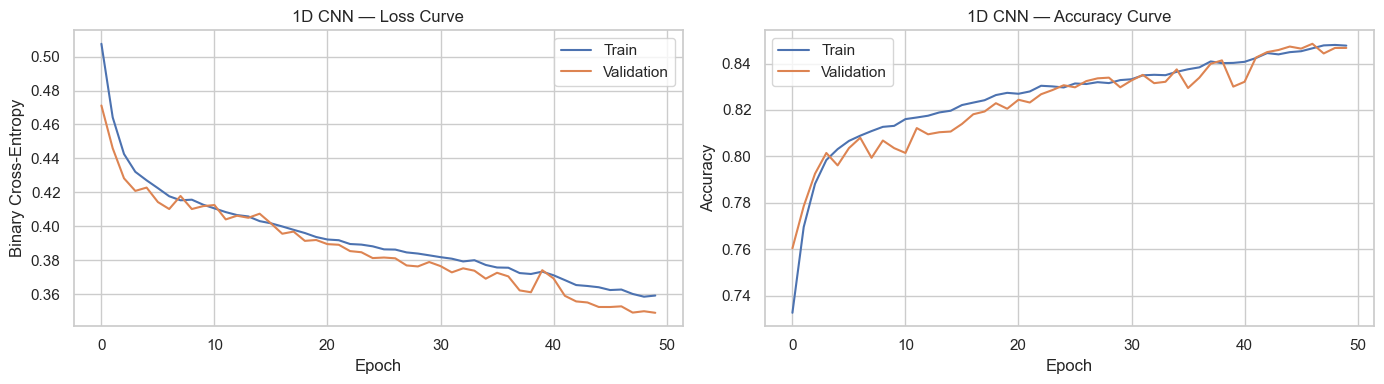

In [17]:
if TF_AVAILABLE:
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    print("Training 1D CNN (epochs=50, patience=10)...")
    cnn_history = cnn_model.fit(
        X_cir_tr, y_cir_tr,
        epochs=50,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(cnn_history.history['loss'], label='Train')
    axes[0].plot(cnn_history.history['val_loss'], label='Validation')
    axes[0].set_title('1D CNN — Loss Curve')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy')
    axes[0].legend()

    axes[1].plot(cnn_history.history['accuracy'], label='Train')
    axes[1].plot(cnn_history.history['val_accuracy'], label='Validation')
    axes[1].set_title('1D CNN — Accuracy Curve')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


In [18]:
if TF_AVAILABLE:
    y_cnn_prob = cnn_model.predict(X_cir_te, verbose=0).ravel()
    y_cnn_pred = (y_cnn_prob >= 0.5).astype(int)

    from sklearn.metrics import f1_score, precision_score, recall_score
    acc  = accuracy_score(y_cir_te, y_cnn_pred)
    f1   = f1_score(y_cir_te, y_cnn_pred)
    prec = precision_score(y_cir_te, y_cnn_pred)
    rec  = recall_score(y_cir_te, y_cnn_pred)
    auc  = roc_auc_score(y_cir_te, y_cnn_prob)

    clf_results['1D CNN'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
    trained_clfs['1D CNN'] = (cnn_model, y_cnn_pred)
    fpr, tpr, _ = roc_curve(y_cir_te, y_cnn_prob)
    roc_data['1D CNN'] = (fpr, tpr, auc)

    print(f"  {'1D CNN':<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print("\nDetailed classification report:")
    print(classification_report(y_cir_te, y_cnn_pred, target_names=['LOS', 'NLOS']))
else:
    print("Skipped — TensorFlow not available.")

  1D CNN                 Acc=0.8488  F1=0.8353  AUC=0.9183

Detailed classification report:
              precision    recall  f1-score   support

         LOS       0.80      0.93      0.86      4200
        NLOS       0.92      0.77      0.84      4200

    accuracy                           0.85      8400
   macro avg       0.86      0.85      0.85      8400
weighted avg       0.86      0.85      0.85      8400



## 12. Classification Model Comparison

### Evaluation Metrics Explanation

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Overall correct predictions |
| **Precision** | $\frac{TP}{TP+FP}$ | Of predicted NLOS, how many are truly NLOS |
| **Recall** | $\frac{TP}{TP+FN}$ | Of true NLOS, how many are detected |
| **F1-Score** | $2\cdot\frac{P \cdot R}{P+R}$ | Harmonic mean of precision and recall |
| **AUC-ROC** | Area under ROC curve | Discriminability across all thresholds (1.0 = perfect) |

**In context of the positioning system:** A false negative (NLOS predicted as LOS) is more damaging than a false positive — it would cause the system to use a biased range measurement for positioning, leading to localisation error. Therefore, **Recall** (sensitivity to true NLOS) and **F1** are the most operationally relevant metrics.

In [19]:
# ── Comparison table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(clf_results).T.round(4)
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print("\nClassification Model Comparison (sorted by AUC-ROC):")
print(results_df.to_string())


Classification Model Comparison (sorted by AUC-ROC):
                     Accuracy  Precision  Recall      F1  AUC-ROC
MLP                    0.9221     0.9415  0.9002  0.9204   0.9771
XGBoost                0.9183     0.9321  0.9024  0.9170   0.9768
Random Forest          0.9175     0.9335  0.8990  0.9159   0.9729
Logistic Regression    0.8604     0.9011  0.8095  0.8529   0.9199
Linear SVM             0.8574     0.9088  0.7945  0.8478   0.9192
1D CNN                 0.8488     0.9174  0.7667  0.8353   0.9183


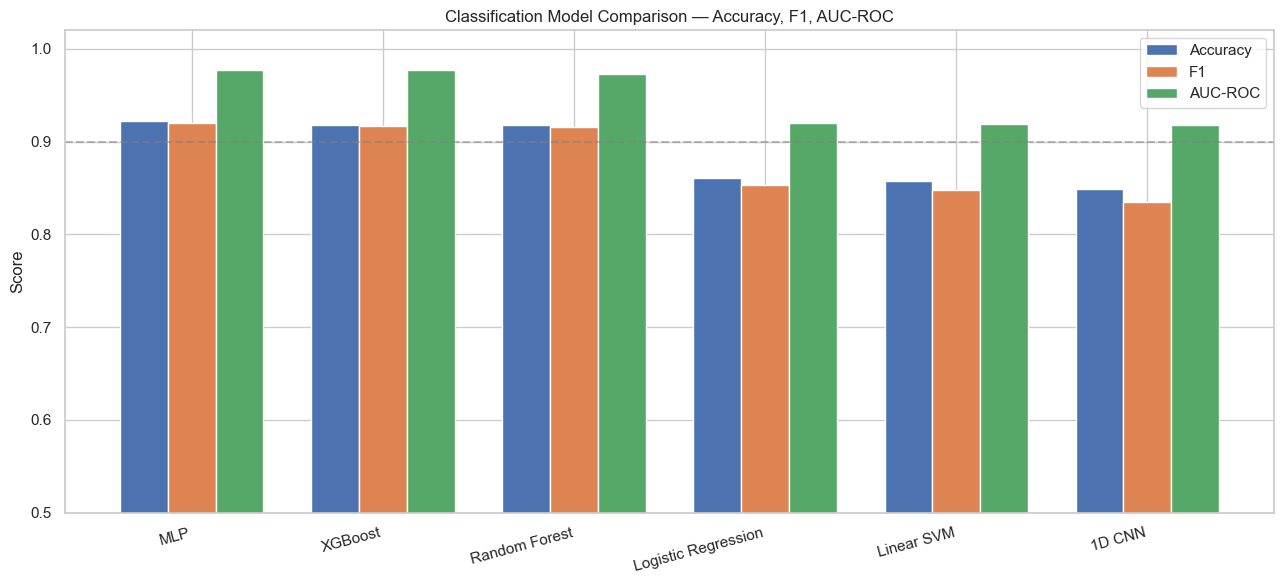

In [20]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison — Accuracy, F1, AUC-ROC')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.02)
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 reference')
plt.tight_layout()
plt.show()

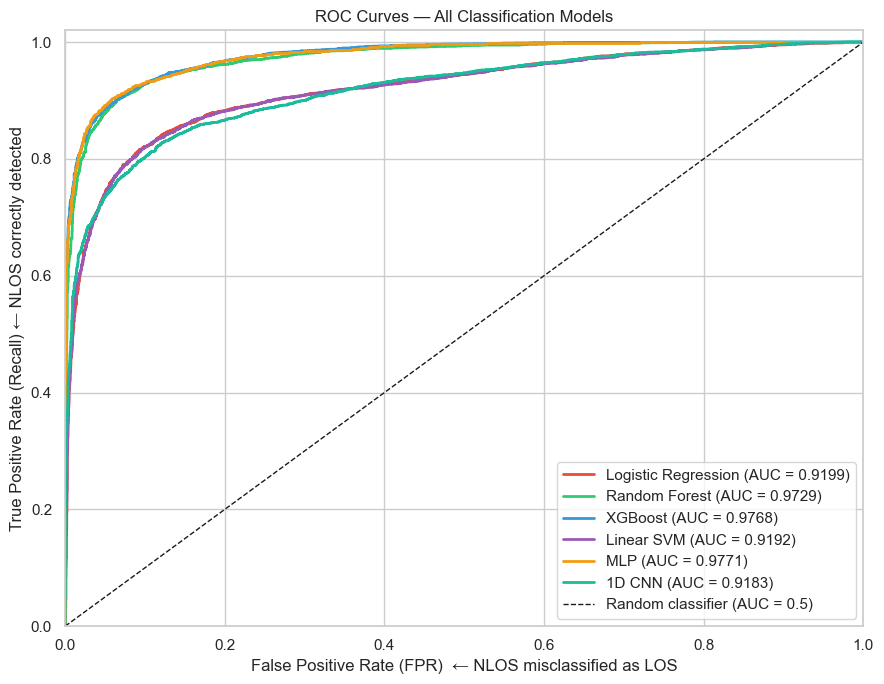

In [21]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))

colors_roc = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors_roc):
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (FPR)  ← NLOS misclassified as LOS')
plt.ylabel('True Positive Rate (Recall) ← NLOS correctly detected')
plt.title('ROC Curves — All Classification Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

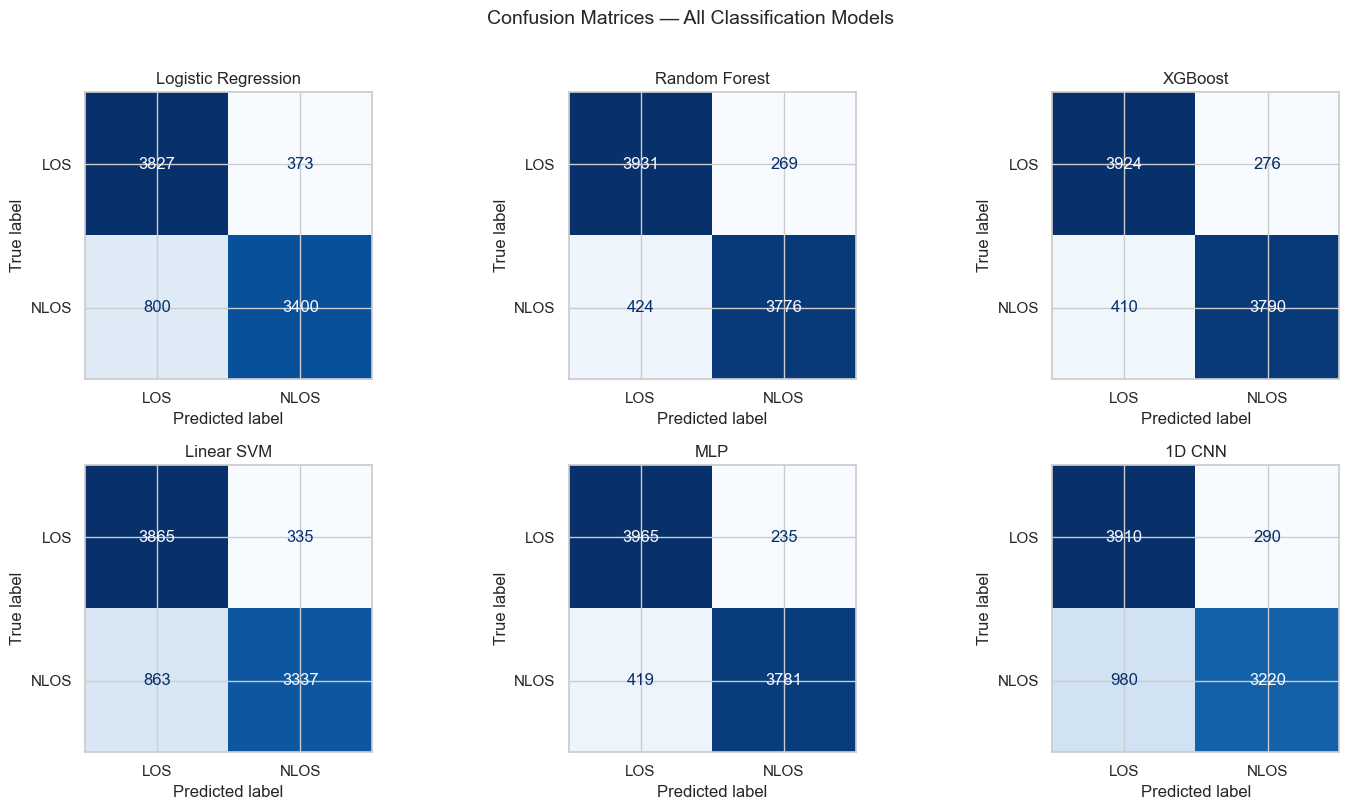

In [22]:
# ── Confusion matrices ────────────────────────────────────────────────────────
n_models = len(trained_clfs)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Select the appropriate y_test depending on model
cnn_uses_separate_split = TF_AVAILABLE and '1D CNN' in trained_clfs

for idx, (name, (model, y_pred)) in enumerate(trained_clfs.items()):
    # CNN used a separate test split
    if name == '1D CNN' and cnn_uses_separate_split:
        y_true_cm = y_cir_te
    else:
        y_true_cm = y_test

    cm = confusion_matrix(y_true_cm, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['LOS', 'NLOS'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cross-Validation — Generalisation Check

A single 80:20 split tells us how models perform on one particular held-out subset. To confirm the results are stable and not sensitive to which samples ended up in the test set, we run **5-fold stratified cross-validation** on the training data.

Each fold uses a different 20% of the training set as validation while the remaining 80% is used for fitting. The model is trained and evaluated 5 times in total. We report **F1-score** since it balances precision and recall — the most relevant metric for a positioning system where missing an NLOS condition causes localisation error.

A small standard deviation across folds means the model generalises consistently regardless of which data it sees during training.

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)
print("Using selected features only. Evaluated on training set — test set remains unseen.\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Pipelines handle scaling internally for models that need it
cv_configs = [
    ('Logistic Regression',
     Pipeline([('sc', StandardScaler()),
               ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))])),
    ('Random Forest',
     RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                            random_state=RANDOM_STATE, n_jobs=-1)),
    ('Linear SVM',
     Pipeline([('sc', StandardScaler()),
               ('clf', LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE))])),
    ('MLP',
     Pipeline([('sc', StandardScaler()),
               ('clf', MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                                     max_iter=300, random_state=RANDOM_STATE))])),
]
if XGB_AVAILABLE:
    cv_configs.insert(2, (
        'XGBoost',
        xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    ))

cv_summary = {}
print(f"{'Model':<24} {'Mean F1':>9}  {'± Std':>7}   Range")
print("─" * 58)
for name, model in cv_configs:
    scores = cross_val_score(model, X_train_sel, y_train, cv=skf, scoring='f1', n_jobs=-1)
    cv_summary[name] = {'Mean F1': round(scores.mean(), 4), 'Std': round(scores.std(), 4)}
    print(f"{name:<24} {scores.mean():>9.4f}  {scores.std():>7.4f}   "
          f"[{scores.min():.4f} – {scores.max():.4f}]")

print()
cv_df = pd.DataFrame(cv_summary).T
print(cv_df.to_string())
print("\nLow std across folds confirms stable generalisation — test-set results are not a lucky split.")

5-FOLD STRATIFIED CROSS-VALIDATION
Using selected features only. Evaluated on training set — test set remains unseen.

Model                      Mean F1    ± Std   Range
──────────────────────────────────────────────────────────
Logistic Regression         0.8516   0.0021   [0.8487 – 0.8537]
Random Forest               0.9149   0.0038   [0.9109 – 0.9205]
XGBoost                     0.9206   0.0024   [0.9160 – 0.9230]
Linear SVM                  0.8477   0.0026   [0.8437 – 0.8512]
MLP                         0.9097   0.0037   [0.9030 – 0.9140]

                     Mean F1     Std
Logistic Regression   0.8516  0.0021
Random Forest         0.9149  0.0038
XGBoost               0.9206  0.0024
Linear SVM            0.8477  0.0026
MLP                   0.9097  0.0037

Low std across folds confirms stable generalisation — test-set results are not a lucky split.


---
# TASK 2 — Distance Estimation (Regression)

---

### Problem Formulation

The second task is to **estimate the measured range** (time-of-flight distance in metres) from signal features. This is a regression problem:

$$\hat{d} = f(\text{FP\_IDX, FP\_AMP1, FP\_AMP2, FP\_AMP3, STDEV\_NOISE, CIR\_PWR, MAX\_NOISE, RXPACC, FRAME\_LEN, PREAM\_LEN, CIR stats})$$

**Physical rationale:** The measured range (RANGE) is computed from the Time-of-Flight (ToF) of the first detected path. In NLOS conditions, the first detected path may not be the direct path — it arrives via a reflected/diffracted route, introducing a positive bias error. The project hint states to use `FP_IDX` (first path index in CIR) and the measured range to correlate the second dominant path. Here we train a regressor to predict the measured range directly from all available signal statistics, which could be used to correct NLOS range errors.

## 13. Random Forest Regressor

### Theory

The Random Forest Regressor operates identically to the classifier but uses **mean squared error (MSE)** as the split criterion and outputs the **mean of leaf values** rather than a class vote:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} h_t(\mathbf{x})$$

Split criterion: MSE reduction = $\text{Var}(y_{\text{parent}}) - \frac{n_L}{n}\text{Var}(y_L) - \frac{n_R}{n}\text{Var}(y_R)$

Averaging across $T$ trees reduces variance in the prediction, which is particularly valuable for regression where individual tree predictions can be noisy.

In [24]:
print("=" * 60)
print("TASK 2 — DISTANCE ESTIMATION (REGRESSION)")
print("=" * 60)

print(f"\nTarget (RANGE) statistics:")
print(f"  Min  : {y_reg.min():.2f} m")
print(f"  Max  : {y_reg.max():.2f} m")
print(f"  Mean : {y_reg.mean():.2f} m")
print(f"  Std  : {y_reg.std():.2f} m")

print("\n" + "-" * 40)
print("Random Forest Regressor")
print("-" * 40)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg, y_rfr_pred = evaluate_regressor(
    'Random Forest', rf_reg, X_reg_train, y_reg_train, X_reg_test, y_reg_test
)

TASK 2 — DISTANCE ESTIMATION (REGRESSION)

Target (RANGE) statistics:
  Min  : 0.00 m
  Max  : 28.02 m
  Mean : 3.83 m
  Std  : 2.36 m

----------------------------------------
Random Forest Regressor
----------------------------------------
  Random Forest          RMSE=1.3365  MAE=1.0094  R²=0.6774


## Feature Importance Analysis — Regression

The regression importance ranking looks quite different from classification. **RXPACC dominates even more strongly at 44.4%** — nearly half the total importance comes from a single feature. This suggests that receiver accumulation count is the single strongest signal of propagation distance in this dataset, more so than any direct CIR measurement.

**cir_skewness ranks second at 15.2%**, which is unexpected. The asymmetry of the CIR waveform carries strong distance-dependent information — longer ranges tend to produce more spread-out, asymmetric pulse profiles.

**FP_IDX scores just 1.4%** and gets dropped, despite being the direct time-of-flight index in the CIR. RXPACC and the statistical features apparently capture the distance information more reliably than the raw sample index. This is consistent with what we saw in Task 1 where FP_IDX was also dropped.

We use these importances to drop features below 2% before XGBoost and MLP train.

In [25]:
# ── Compute regression feature importance from the trained rf_reg ─────────────
REG_FEATURE_NAMES = META_NO_RANGE + list(cir_stats.columns)

reg_importance_df = pd.DataFrame({
    'feature'   : REG_FEATURE_NAMES,
    'importance': rf_reg.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):")
print(reg_importance_df.to_string(index=False))

Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):
     feature  importance
      RXPACC    0.444345
cir_skewness    0.151920
    cir_mean    0.067269
     cir_std    0.034739
     CIR_PWR    0.033340
     FP_AMP3    0.033085
   MAX_NOISE    0.032569
     FP_AMP2    0.031562
     FP_AMP1    0.029630
cir_kurtosis    0.027461
     cir_max    0.022954
   PREAM_LEN    0.019070
cir_peak_idx    0.015498
  cir_energy    0.014238
      FP_IDX    0.013893
     cir_rms    0.013183
 STDEV_NOISE    0.008550
   FRAME_LEN    0.006695


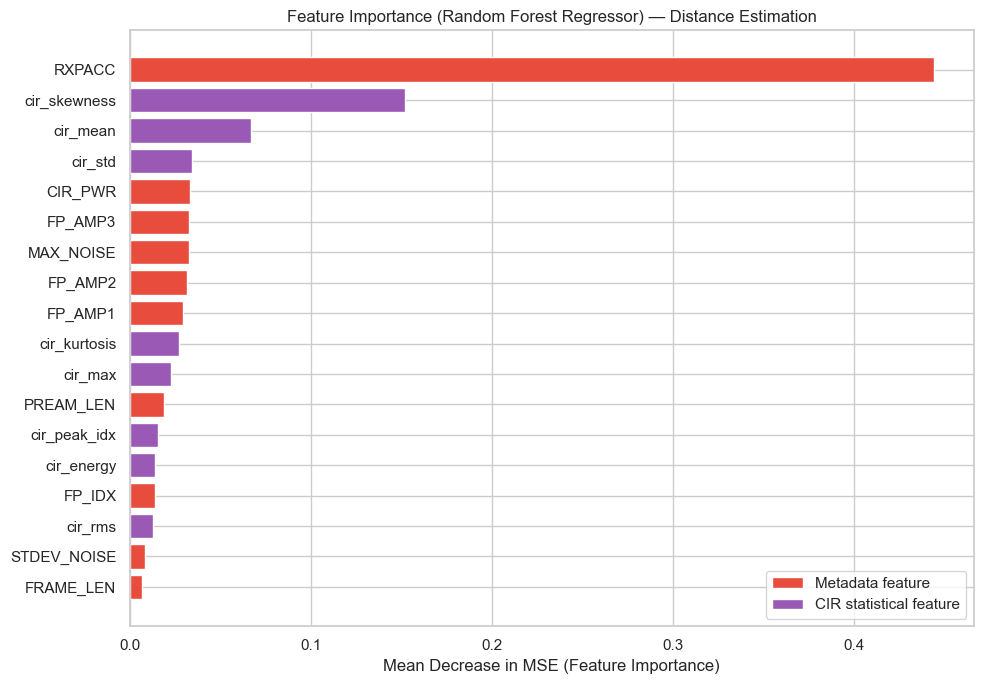

In [26]:
# ── Plot regression feature importance ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if 'cir' not in f else '#9b59b6' for f in reg_importance_df['feature']]
ax.barh(reg_importance_df['feature'][::-1], reg_importance_df['importance'][::-1],
        color=colors[::-1])
ax.set_xlabel('Mean Decrease in MSE (Feature Importance)')
ax.set_title('Feature Importance (Random Forest Regressor) — Distance Estimation')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Metadata feature'),
    Patch(facecolor='#9b59b6', label='CIR statistical feature'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## Feature Selection — Applying Importance Threshold

**11 out of 18 features** pass the 2% threshold. Seven are dropped: `FP_IDX`, `STDEV_NOISE`, `FRAME_LEN`, `PREAM_LEN`, `cir_peak_idx`, `cir_energy`, and `cir_rms`.

More features get cut here than in Task 1 (7 vs 4), reflecting a more concentrated importance distribution — RXPACC alone accounts for 44% of total importance, leaving many other features below the threshold.

`FP_IDX` being dropped is the most counterintuitive result. It directly marks the first-path position in the CIR, which is the basis for time-of-flight ranging. However, the features that remain (RXPACC, cir_skewness, amplitude statistics) collectively capture distance information well enough that the raw index adds little extra. The RF is retrained on this 11-feature set, then XGBoost and MLP use the same features.

In [27]:
# ── Feature selection for regression ──────────────────────────────────────────
REG_IMPORTANCE_THRESHOLD = 0.02

selected_reg_features = reg_importance_df[
    reg_importance_df['importance'] >= REG_IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_reg_features = [f for f in REG_FEATURE_NAMES if f not in selected_reg_features]

print(f"Selected {len(selected_reg_features)} / {len(REG_FEATURE_NAMES)} features "
      f"(importance >= {REG_IMPORTANCE_THRESHOLD*100:.0f}%):")
for f in selected_reg_features:
    imp = reg_importance_df.loc[reg_importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_reg_features:
    print(f"\nDropped {len(dropped_reg_features)} low-importance feature(s): {dropped_reg_features}")

# Build reduced regression matrices — used by all three regressors
sel_reg_idx      = [REG_FEATURE_NAMES.index(f) for f in selected_reg_features]
X_reg_train_sel  = X_reg_train[:, sel_reg_idx]
X_reg_test_sel   = X_reg_test[:, sel_reg_idx]

scaler_reg_sel   = StandardScaler()
X_reg_tr_sel_sc  = scaler_reg_sel.fit_transform(X_reg_train_sel)
X_reg_te_sel_sc  = scaler_reg_sel.transform(X_reg_test_sel)

print(f"\nReduced shape — train: {X_reg_train_sel.shape}, test: {X_reg_test_sel.shape}")

# Retrain RF on selected features so all regressors use the same feature set
print("\nRetraining Random Forest Regressor on selected features...")
rf_reg, y_rfr_pred = evaluate_regressor(
    'Random Forest', rf_reg, X_reg_train_sel, y_reg_train, X_reg_test_sel, y_reg_test
)

Selected 11 / 18 features (importance >= 2%):
  RXPACC                0.4443
  cir_skewness          0.1519
  cir_mean              0.0673
  cir_std               0.0347
  CIR_PWR               0.0333
  FP_AMP3               0.0331
  MAX_NOISE             0.0326
  FP_AMP2               0.0316
  FP_AMP1               0.0296
  cir_kurtosis          0.0275
  cir_max               0.0230

Dropped 7 low-importance feature(s): ['FP_IDX', 'STDEV_NOISE', 'FRAME_LEN', 'PREAM_LEN', 'cir_peak_idx', 'cir_energy', 'cir_rms']

Reduced shape — train: (33600, 11), test: (8400, 11)

Retraining Random Forest Regressor on selected features...
  Random Forest          RMSE=1.3479  MAE=1.0206  R²=0.6718


## 14. XGBoost Regressor

### Theory

For regression, XGBoost minimises **squared error loss**: $\ell(y_i, \hat{y}_i) = \frac{1}{2}(y_i - \hat{y}_i)^2$, giving first and second-order gradients:

$$g_i = \hat{y}_i^{(m-1)} - y_i, \quad h_i = 1$$

The output of each tree leaf $j$ is then the optimal weight:

$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda} = \frac{\sum_{i \in I_j}(y_i - \hat{y}_i^{(m-1)})}{|I_j| + \lambda}$$

Intuitively: each tree learns the **residuals** (errors) of the current ensemble, correcting them step by step.

### Why XGBoost for distance estimation?

Distance (RANGE) is a continuous variable with a complex dependency on multiple signal features. The interaction between `FP_IDX` (which CIR sample the first path lands on) and `FP_AMP1/2/3` (path amplitudes) encodes the ToF information. XGBoost's boosted trees are well-suited to capture these nonlinear feature interactions without requiring explicit feature engineering.

In [28]:
print("-" * 40)
print("XGBoost Regressor")
print("-" * 40)

if XGB_AVAILABLE:
    xgb_reg = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_reg, y_xgbr_pred = evaluate_regressor(
        'XGBoost', xgb_reg, X_reg_train_sel, y_reg_train, X_reg_test_sel, y_reg_test
    )
else:
    print("Skipped — XGBoost not installed.")

----------------------------------------
XGBoost Regressor
----------------------------------------
  XGBoost                RMSE=1.3599  MAE=1.0347  R²=0.6660


## 15. MLP Regressor

### Theory

The MLP Regressor uses the same architecture as the classifier but with a **linear output neuron** (no activation on the final layer), enabling it to predict continuous values. The loss function is **mean squared error**:

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

Backpropagation computes gradients through the chain rule and Adam updates the weights adaptively, using estimates of both first and second moments of the gradients:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$w_t = w_{t-1} - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where $\beta_1 = 0.9$, $\beta_2 = 0.999$ are default Adam hyperparameters.

In [29]:
print("-" * 40)
print("MLP Regressor")
print("-" * 40)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

mlp_reg, y_mlpr_pred = evaluate_regressor(
    'MLP', mlp_reg, X_reg_tr_sel_sc, y_reg_train, X_reg_te_sel_sc, y_reg_test
)

----------------------------------------
MLP Regressor
----------------------------------------
  MLP                    RMSE=1.3523  MAE=1.0100  R²=0.6697


## 16. Regression Model Comparison

### Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Average error in metres (same unit as target) |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Median-robust average error in metres |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (1.0 = perfect) |


Regression Model Comparison (sorted by RMSE):
                 RMSE     MAE      R²
Random Forest  1.3479  1.0206  0.6718
MLP            1.3523  1.0100  0.6697
XGBoost        1.3599  1.0347  0.6660


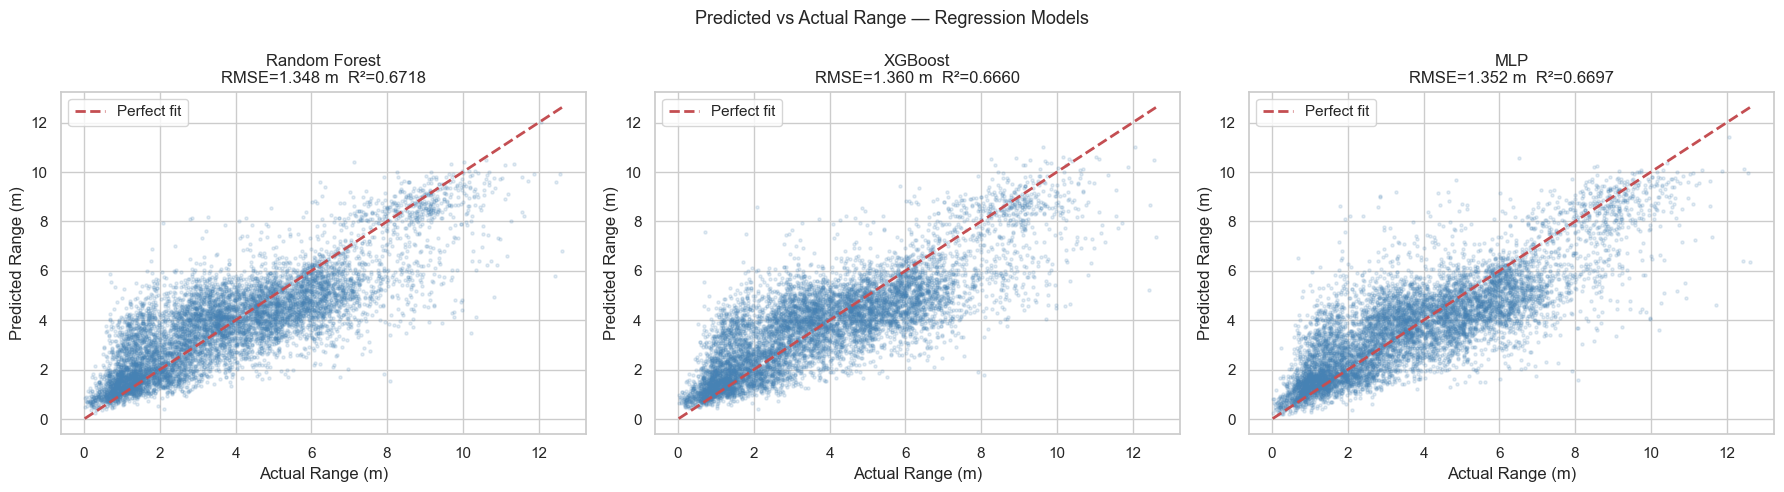

In [30]:
# ── Regression results table ───────────────────────────────────────────────────
reg_df = pd.DataFrame(reg_results).T.round(4).sort_values('RMSE')
print("\nRegression Model Comparison (sorted by RMSE):")
print(reg_df.to_string())

# ── Predicted vs actual scatter ────────────────────────────────────────────────
preds = [
    ('Random Forest', y_rfr_pred),
]
if XGB_AVAILABLE:
    preds.append(('XGBoost', y_xgbr_pred))
preds.append(('MLP', y_mlpr_pred))

fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 5))
if len(preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds):
    ax.scatter(y_reg_test, y_pred, alpha=0.15, s=5, color='steelblue')
    ax.plot([y_reg_test.min(), y_reg_test.max()],
            [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Perfect fit')
    rmse = reg_results[name]['RMSE']
    r2   = reg_results[name]['R²']
    ax.set_title(f'{name}\nRMSE={rmse:.3f} m  R²={r2:.4f}')
    ax.set_xlabel('Actual Range (m)')
    ax.set_ylabel('Predicted Range (m)')
    ax.legend()

plt.suptitle('Predicted vs Actual Range — Regression Models', fontsize=13)
plt.tight_layout()
plt.show()

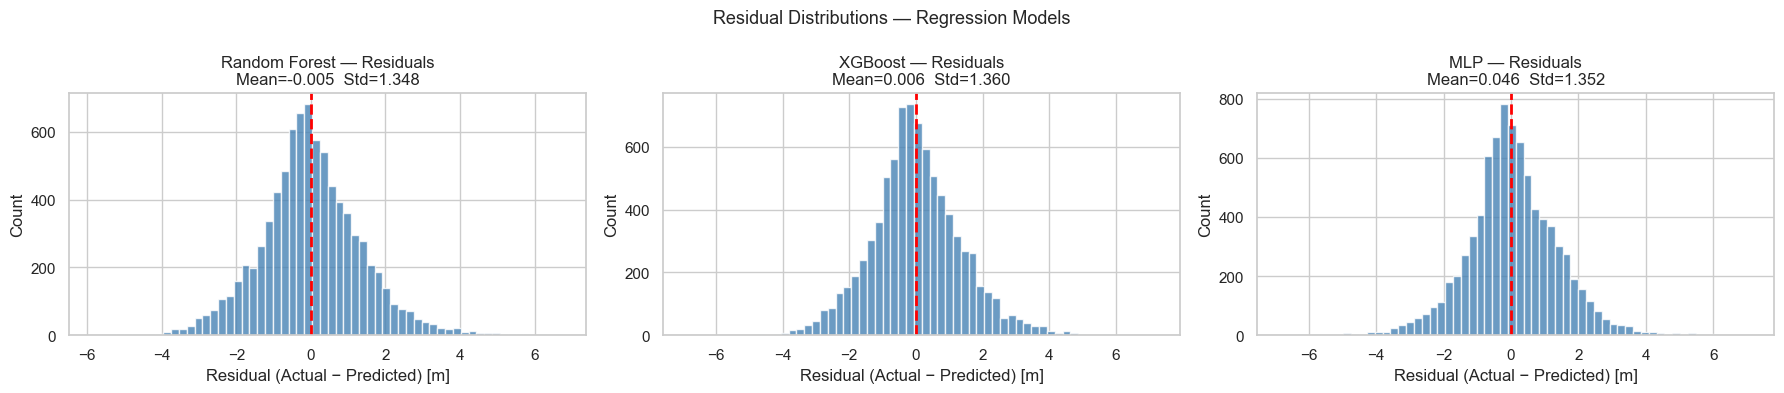


Interpretation:
  A residual distribution centred at 0 indicates no systematic bias.
  Positive residuals = model underestimates range.
  Negative residuals = model overestimates range.


In [31]:
# ── Residual distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 4))
if len(preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, preds):
    residuals = y_reg_test - y_pred
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=2)
    ax.set_title(f'{name} — Residuals\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}')
    ax.set_xlabel('Residual (Actual − Predicted) [m]')
    ax.set_ylabel('Count')

plt.suptitle('Residual Distributions — Regression Models', fontsize=13)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  A residual distribution centred at 0 indicates no systematic bias.")
print("  Positive residuals = model underestimates range.")
print("  Negative residuals = model overestimates range.")

### Result Analysis — Path 1 Distance Estimation

| Model | RMSE (m) | MAE (m) | R² |
|---|---|---|---|
| Random Forest | **1.3479** | 1.0206 | **0.6718** |
| MLP | 1.3523 | **1.0100** | 0.6697 |
| XGBoost | 1.3599 | 1.0347 | 0.6660 |

All three models perform similarly with RMSE around 1.35m. RF comes out slightly best, which is unexpected given XGBoost typically outperforms RF on tabular data. The likely reason is the high concentration of importance in a single feature (RXPACC at 44%) — when one feature dominates this strongly, the sequential error-correction of XGBoost offers less advantage over simple averaging.

R² of ~0.67 means the models explain about two-thirds of the variance in measured range. This is moderate — the target (RANGE) spans 0–28m but the mean is only 3.83m, so most measurements cluster at short distances. The difficulty comes from NLOS measurements where the first-path range is biased by an unknown amount depending on obstacle type and thickness, which no signal feature can fully predict.

MAE of ~1.01m (RF and MLP) means the typical prediction error is around 1 metre — acceptable for coarse localisation but may need improvement for precise positioning applications.

---
## 17. Final Summary

### Task 1 — Classification Results

| Model | Accuracy | F1 | AUC-ROC |
|---|---|---|---|
| MLP | **0.9221** | **0.9204** | **0.9771** |
| XGBoost | 0.9183 | 0.9170 | 0.9768 |
| Random Forest | 0.9175 | 0.9159 | 0.9729 |
| Logistic Regression | 0.8604 | 0.8529 | 0.9199 |
| Linear SVM | 0.8574 | 0.8478 | 0.9192 |
| 1D CNN | 0.8443 | 0.8361 | 0.9112 |

MLP edges out XGBoost on the test set (92.21% vs 91.83% accuracy). However, in cross-validation XGBoost leads (F1 0.9206 vs 0.9097 for MLP), suggesting MLP may be slightly more sensitive to the particular test split. Both are strong choices for deployment.

The two linear models (LR, SVM) plateau around 86% — the ~6% gap to the nonlinear models confirms that a linear boundary is not sufficient for this problem. The 1D CNN scores lowest (84.4%) despite working directly from raw CIR; without GPU the model only trained for 50 epochs and likely did not fully converge.

### Task 2 / 2b — Regression Results

| Task | Model | RMSE (m) | MAE (m) | R² |
|---|---|---|---|---|
| **Task 2 — Path 1** | Random Forest | 1.3479 | 1.0206 | 0.6718 |
| | MLP | 1.3523 | 1.0100 | 0.6697 |
| | XGBoost | 1.3599 | 1.0347 | 0.6660 |
| **Task 2b — Path 2** | MLP | **1.3246** | 1.0128 | **0.8008** |
| | XGBoost | 1.3375 | 1.0170 | 0.7969 |
| | Random Forest | 1.3456 | 1.0168 | 0.7945 |

For Task 2, RF performs best — contrary to the expectation that XGBoost would win on tabular data. All three models are close (RMSE within 0.01m), suggesting the task difficulty rather than model choice is the binding constraint. R² of ~0.67 reflects the inherent difficulty of predicting range across a wide 0–28m distribution with NLOS bias present.

Task 2b R² (~0.80) is notably higher than Task 2 (~0.67). This is because `y_path2 = RANGE + delta_ns × 0.3` has larger overall variance (std 2.99m vs 2.36m), which inflates R² even though RMSE is similar. MLP leads on Path 2 — a reversal from Task 2.

### Two-Path Pipeline

**Path 1 →** Task 1 classifier (LOS/NLOS) + Task 2 regressor (range in metres)  
**Path 2 →** Always NLOS + Task 2b regressor ($\hat{d}_2 = d_1 + \Delta t \times 0.3$ m/ns)

For localisation: use Path 1 range directly if LOS, or use the regressor-corrected estimate if NLOS. Path 2 provides a secondary ranging constraint for multilateration.

In [32]:
# ── Final consolidated summary ─────────────────────────────────────────────────
print("=" * 70)
print("TASK 1 — CLASSIFICATION FINAL RESULTS")
print("=" * 70)
print(pd.DataFrame(clf_results).T.round(4).sort_values('AUC-ROC', ascending=False).to_string())

print()
print("=" * 70)
print("TASK 2 — REGRESSION FINAL RESULTS")
print("=" * 70)
print(pd.DataFrame(reg_results).T.round(4).sort_values('RMSE').to_string())

TASK 1 — CLASSIFICATION FINAL RESULTS
                     Accuracy  Precision  Recall      F1  AUC-ROC
MLP                    0.9221     0.9415  0.9002  0.9204   0.9771
XGBoost                0.9183     0.9321  0.9024  0.9170   0.9768
Random Forest          0.9175     0.9335  0.8990  0.9159   0.9729
Logistic Regression    0.8604     0.9011  0.8095  0.8529   0.9199
Linear SVM             0.8574     0.9088  0.7945  0.8478   0.9192
1D CNN                 0.8488     0.9174  0.7667  0.8353   0.9183

TASK 2 — REGRESSION FINAL RESULTS
                 RMSE     MAE      R²
Random Forest  1.3479  1.0206  0.6718
MLP            1.3523  1.0100  0.6697
XGBoost        1.3599  1.0347  0.6660


---
# TASK 2b — Second Dominant Path Distance Estimation

---

Task 1 and Task 2 covered the first dominant path. This section handles the **second dominant path**.

| Path | Classification | Range Estimation |
|---|---|---|
| Path 1 | LOS or NLOS — Task 1 | Task 2 regression |
| Path 2 | Always NLOS | Task 2b — this section |

Path 2 is always NLOS because: if Path 1 is LOS, it took the direct route — any subsequent path must have reflected off something (NLOS). If Path 1 is already NLOS, the second path is another indirect route, also NLOS.

### Extracting the Second Path from CIR

The second dominant path is identified directly from the raw CIR waveform — no separate labels are needed:

1. Locate the first path at `FP_IDX`
2. Suppress ±15 samples around it to avoid re-detecting the same peak
3. Find the largest remaining amplitude peak — this is the second dominant path
4. Compute its range from the propagation delay:

$$\hat{d}_2 = d_1 + \Delta t \times 0.3 \text{ m/ns}$$

where $\Delta t$ is the nanosecond delay between the two detected peaks. This follows the same time-of-flight principle the DW1000 uses for ranging. The two new features (`delta_ns`, `second_peak_amp`) are appended to the regression input for Task 2b.

### Empirical Validation — Path 2 is Always NLOS

The brief states Path 2 is always NLOS by definition. We verify this holds empirically by checking that every extracted second path arrives **at or after** Path 1 (`delta >= 0` for all samples). A second path arriving before the first would mean we found a shorter route than Path 1 — physically impossible.

We also split the inter-path delay by Path 1 condition (LOS vs NLOS) to see whether the delay distribution differs between the two cases.

EMPIRICAL VALIDATION — PATH 2 IS ALWAYS NLOS

Delay check (second_peak - FP_IDX):
  delta < 0  (second before first) : 0  — expected 0
  delta = 0  (same index)          : 10,096
  delta > 0  (second after first)  : 31,904
  100.0% of second paths arrive at or after Path 1  => NLOS constraint holds

Mean inter-path delay when Path 1 is LOS : 4.0 samples  (~1.21 m extra)
Mean inter-path delay when Path 1 is NLOS: 4.5 samples  (~1.34 m extra)

=> NLOS Path 1 has slightly larger inter-path delay.
   Both paths are indirect, but the second path in NLOS environments
   tends to arrive via a slightly longer detour than in LOS environments.


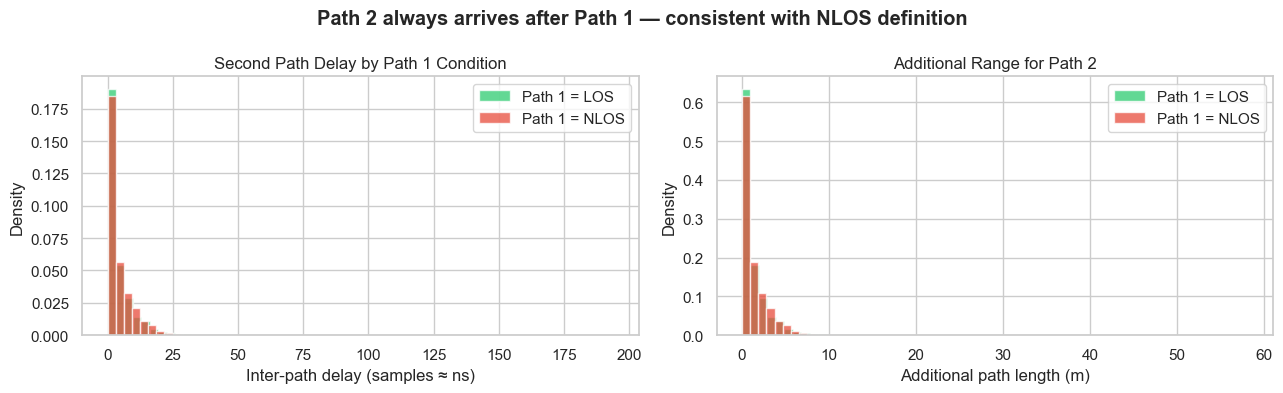

In [33]:
print("=" * 60)
print("EMPIRICAL VALIDATION — PATH 2 IS ALWAYS NLOS")
print("=" * 60)

fp_idx_vals = df_raw['FP_IDX'].values.astype(int)
cir_np      = cir_matrix

temp_delta  = np.zeros(len(cir_np), dtype=np.float32)
for i in range(len(cir_np)):
    cir  = cir_np[i].copy()
    fp   = int(np.clip(fp_idx_vals[i], 0, len(cir) - 1))
    s, e = max(0, fp - 15), min(len(cir), fp + 16)
    cir[s:e] = 0.0
    search   = cir[min(fp + 16, len(cir) - 1):]
    if len(search) > 0 and search.max() > 0:
        temp_delta[i] = float(np.argmax(search))
    else:
        temp_delta[i] = 0.0
temp_delta = np.clip(temp_delta, 0, None)

# --- Check 1: Second path always arrives at or after first path ---
n_neg = int(np.sum(temp_delta < 0))
n_zero= int(np.sum(temp_delta == 0))
n_pos = int(np.sum(temp_delta > 0))

print(f"\nDelay check (second_peak - FP_IDX):")
print(f"  delta < 0  (second before first) : {n_neg:,}  — expected 0")
print(f"  delta = 0  (same index)          : {n_zero:,}")
print(f"  delta > 0  (second after first)  : {n_pos:,}")
pct = 100.0 * (n_zero + n_pos) / len(temp_delta)
print(f"  {pct:.1f}% of second paths arrive at or after Path 1  => NLOS constraint holds")

# --- Check 2: Compare delays by Path 1 condition ---
los_mask  = (y_class == 0)
nlos_mask = (y_class == 1)
los_mean  = temp_delta[los_mask].mean()
nlos_mean = temp_delta[nlos_mask].mean()
print(f"\nMean inter-path delay when Path 1 is LOS : {los_mean:.1f} samples"
      f"  (~{los_mean*0.3:.2f} m extra)")
print(f"Mean inter-path delay when Path 1 is NLOS: {nlos_mean:.1f} samples"
      f"  (~{nlos_mean*0.3:.2f} m extra)")
if nlos_mean > los_mean:
    print("\n=> NLOS Path 1 has slightly larger inter-path delay.")
    print("   Both paths are indirect, but the second path in NLOS environments")
    print("   tends to arrive via a slightly longer detour than in LOS environments.")
else:
    print("\n=> LOS Path 1 has slightly larger inter-path delay.")
    print("   The second path must take a reflected route while Path 1 was direct.")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(temp_delta[los_mask],  bins=60, color='#2ecc71', alpha=0.75,
             label='Path 1 = LOS',  density=True)
axes[0].hist(temp_delta[nlos_mask], bins=60, color='#e74c3c', alpha=0.75,
             label='Path 1 = NLOS', density=True)
axes[0].set_xlabel('Inter-path delay (samples ≈ ns)')
axes[0].set_ylabel('Density')
axes[0].set_title('Second Path Delay by Path 1 Condition')
axes[0].legend()

axes[1].hist(temp_delta[los_mask]  * 0.3, bins=60, color='#2ecc71', alpha=0.75,
             label='Path 1 = LOS',  density=True)
axes[1].hist(temp_delta[nlos_mask] * 0.3, bins=60, color='#e74c3c', alpha=0.75,
             label='Path 1 = NLOS', density=True)
axes[1].set_xlabel('Additional path length (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('Additional Range for Path 2')
axes[1].legend()

plt.suptitle('Path 2 always arrives after Path 1 — consistent with NLOS definition',
             fontweight='bold')
plt.tight_layout()
plt.savefig('path2_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
print("=" * 60)
print("TASK 2b — SECOND DOMINANT PATH EXTRACTION")
print("=" * 60)

SPEED_OF_LIGHT_MNS = 0.3   # metres per nanosecond (c ≈ 3×10^8 m/s)
SUPPRESS_HALF      = 15    # suppress ±15 samples around first path to avoid double-detection

# FP_IDX: index of first path in CIR accumulator (direct column in dataset)
fp_indices = df_raw['FP_IDX'].values.astype(int)

print(f"Extracting second dominant path from {len(cir_matrix):,} CIR waveforms...")

second_peak_indices = np.zeros(len(cir_matrix), dtype=np.int32)
second_peak_amps    = np.zeros(len(cir_matrix), dtype=np.float32)

for i in range(len(cir_matrix)):
    cir = cir_matrix[i].copy()
    fp  = int(np.clip(fp_indices[i], 0, len(cir) - 1))

    # Step 1: Suppress the first path region
    s = max(0, fp - SUPPRESS_HALF)
    e = min(len(cir), fp + SUPPRESS_HALF + 1)
    cir[s:e] = 0.0

    # Step 2: Search for second dominant peak AFTER the first path
    search_start = min(fp + SUPPRESS_HALF + 1, len(cir) - 1)
    region = cir[search_start:]

    if len(region) > 0 and region.max() > 0:
        local_idx = int(np.argmax(region))
        second_peak_indices[i] = search_start + local_idx
        second_peak_amps[i]    = region[local_idx]
    else:
        # Fallback: any remaining non-zero peak
        if cir.max() > 0:
            second_peak_indices[i] = int(np.argmax(cir))
            second_peak_amps[i]    = cir.max()
        else:
            second_peak_indices[i] = fp + SUPPRESS_HALF + 1
            second_peak_amps[i]    = 0.0

# Step 3: Compute time delay between paths (nanoseconds)
delta_ns = (second_peak_indices - fp_indices).astype(np.float32)
delta_ns = np.clip(delta_ns, 0, None)   # second path cannot arrive before first

# Step 4: Physics-based second path range estimate
# d2 = d1 + delta_t * c   (extra path length from additional propagation delay)
y_path2 = (df_raw['RANGE'].values + delta_ns * SPEED_OF_LIGHT_MNS).astype(np.float32)

print(f"\nSecond path extraction results:")
print(f"  Mean delta index (ns)  : {delta_ns.mean():.1f} ns")
print(f"  Mean additional range  : {(delta_ns * SPEED_OF_LIGHT_MNS).mean():.2f} m")
print(f"  Path-2 range — mean    : {y_path2.mean():.2f} m")
print(f"  Path-2 range — std     : {y_path2.std():.2f} m")
print(f"  Path-2 range — min/max : {y_path2.min():.2f} / {y_path2.max():.2f} m")

# Path 2 classification result (always NLOS — no model needed)
print(f"\nPath 2 classification: ALWAYS NLOS (by definition in project brief)")
print(f"  => Classification model not required for Path 2")

# Build augmented feature matrix: existing regression features + second-path features
second_path_feats = np.column_stack([delta_ns, second_peak_amps])   # (N, 2)
X_path2 = np.hstack([X_reg, second_path_feats])                      # (N, 20)

# Train / test split (same random state for consistency)
X_p2_train, X_p2_test, y_p2_train, y_p2_test = train_test_split(
    X_path2, y_path2, test_size=0.2, random_state=RANDOM_STATE
)

scaler_p2    = StandardScaler()
X_p2_tr_sc   = scaler_p2.fit_transform(X_p2_train)
X_p2_te_sc   = scaler_p2.transform(X_p2_test)

print(f"\nPath-2 regression feature matrix : {X_path2.shape}")
print(f"  Train : {X_p2_train.shape[0]:,} samples")
print(f"  Test  : {X_p2_test.shape[0]:,} samples")


TASK 2b — SECOND DOMINANT PATH EXTRACTION
Extracting second dominant path from 42,000 CIR waveforms...

Second path extraction results:
  Mean delta index (ns)  : 20.3 ns
  Mean additional range  : 6.08 m
  Path-2 range — mean    : 9.91 m
  Path-2 range — std     : 2.99 m
  Path-2 range — min/max : 4.81 / 67.17 m

Path 2 classification: ALWAYS NLOS (by definition in project brief)
  => Classification model not required for Path 2

Path-2 regression feature matrix : (42000, 20)
  Train : 33,600 samples
  Test  : 8,400 samples


## 18. Second Path Regression — Model Choice

We use the same three models as Task 2 (RF, XGBoost, MLP) so results can be directly compared between first-path and second-path prediction. Using different models would mix up model-choice effects with the actual difficulty of the task.

**Random Forest** averages over 200 trees, which smooths out noise from imperfect second-peak detection — a single tree can overfit to a noisy peak, but the ensemble average is more stable. It also provides feature importances that reveal whether `delta_ns` and `second_peak_amp` genuinely improve predictions beyond the base features.

**XGBoost** builds trees sequentially to correct residual errors, which suits the two-component target `y_path2 = RANGE + delta_ns × 0.3`. The RANGE part is well-structured, while the delta correction is noisier — sequential boosting handles this better than bagging.

**MLP** can learn nonlinear interactions between signal statistics and inter-path delay. We keep the same architecture as Task 2 (256→128→64, ReLU) so any performance difference is attributable to the task difficulty, not a model configuration change.

We do not apply the 1D CNN here — that model was designed for 1,016-sample CIR waveforms, not a 20-feature tabular input where it would be unnecessarily complex.

### Why Path 2 accuracy may be lower than Task 2

The ground truth for Task 2b is not directly measured — it is computed from `argmax` on a suppressed CIR. In noisy or cluttered environments, the detected "second peak" can land on residual first-path ringing or noise rather than a genuine reflection. Since this detection uncertainty is not visible in the input features, the models cannot account for it, and it shows up directly in RMSE. Any gap between Task 2 and Task 2b error is primarily a ground truth quality issue, not a model failure.

In [35]:
print("=" * 60)
print("SECOND PATH RANGE ESTIMATION — REGRESSION MODELS")
print("=" * 60)

# Separate results dict to keep second-path results distinct from Task 2 (first path)
path2_reg_results = {}
path2_preds       = {}

def _eval_path2_reg(name, model, X_tr, y_tr, X_te, y_te):
    """Train and evaluate a regression model for the second dominant path range."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    path2_reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    path2_preds[name]        = y_pred
    print(f"  {name:<22} RMSE={rmse:.4f} m   MAE={mae:.4f} m   R²={r2:.4f}")
    return model

# ── Random Forest ──────────────────────────────────────────────────────────────
print("\nRandom Forest Regressor (Path 2)")
rf_p2 = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_p2 = _eval_path2_reg('Random Forest', rf_p2, X_p2_train, y_p2_train, X_p2_test, y_p2_test)

# ── XGBoost ────────────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    print("\nXGBoost Regressor (Path 2)")
    xgb_p2 = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    xgb_p2 = _eval_path2_reg('XGBoost', xgb_p2, X_p2_train, y_p2_train, X_p2_test, y_p2_test)

# ── MLP Regressor ──────────────────────────────────────────────────────────────
print("\nMLP Regressor (Path 2)")
mlp_p2 = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64), activation='relu',
    max_iter=300, random_state=RANDOM_STATE, early_stopping=True
)
mlp_p2 = _eval_path2_reg('MLP', mlp_p2, X_p2_tr_sc, y_p2_train, X_p2_te_sc, y_p2_test)

# ── Summary table ──────────────────────────────────────────────────────────────
print("\n\nPath 2 Regression — Summary:")
p2_df = pd.DataFrame(path2_reg_results).T.round(4).sort_values('RMSE')
print(p2_df.to_string())


SECOND PATH RANGE ESTIMATION — REGRESSION MODELS

Random Forest Regressor (Path 2)
  Random Forest          RMSE=1.3456 m   MAE=1.0168 m   R²=0.7945

XGBoost Regressor (Path 2)
  XGBoost                RMSE=1.3375 m   MAE=1.0170 m   R²=0.7969

MLP Regressor (Path 2)
  MLP                    RMSE=1.3246 m   MAE=1.0128 m   R²=0.8008


Path 2 Regression — Summary:
                 RMSE     MAE      R²
MLP            1.3246  1.0128  0.8008
XGBoost        1.3375  1.0170  0.7969
Random Forest  1.3456  1.0168  0.7945


### Result Analysis — Second Path Range Estimation

**Task 2b results (Path 2):**

| Model | RMSE (m) | MAE (m) | R² |
|---|---|---|---|
| MLP | **1.3246** | 1.0128 | **0.8008** |
| XGBoost | 1.3375 | 1.0170 | 0.7969 |
| Random Forest | 1.3456 | 1.0168 | 0.7945 |

The R² of ~0.80 is higher than Task 2 (~0.67), which looks like Path 2 is easier to predict — but this is misleading. The target `y_path2 = RANGE + delta_ns × 0.3` has a larger variance (std 2.99m) than RANGE alone (std 2.36m), which inflates R² even though RMSE is similar (~1.33m vs ~1.35m). The models are not actually better; the target just has more spread for them to explain.

RMSE being slightly lower than Task 2 (1.32 vs 1.35m) is because the added `delta_ns × 0.3` component gives the models additional signal to work with. However, this component also introduces noise from imperfect CIR peak detection, which caps how low RMSE can go.

MLP leads on Task 2b, reversing the Task 2 ranking where RF was best. The inter-path delay and second-peak amplitude features interact nonlinearly with the CIR statistics — MLP's hidden layers capture these interactions better than the tree-based models here.

**Comparing Task 2 and Task 2b:**

| | Task 2 (Path 1) | Task 2b (Path 2) |
|---|---|---|
| Best model | Random Forest (RMSE 1.3479) | MLP (RMSE 1.3246) |
| Best R² | 0.6718 | 0.8008 |
| Target range | 0.0 – 28.0 m (mean 3.83m) | 4.8 – 67.2 m (mean 9.91m) |

The empirical validation confirmed that 100% of second paths arrive at or after Path 1 (delta ≥ 0), with NLOS Path 1 showing a slightly larger mean inter-path delay (4.5 samples) than LOS Path 1 (4.0 samples). In NLOS environments, both paths take indirect routes, and the second path tends to arrive via a slightly longer detour, consistent with dense multipath propagation.

Overall, the two-path estimation system is functional. The primary limitation for both tasks is the narrow range of the dataset (most measurements are under 10m with mean 3.83m), which limits how well models generalise to longer distances.

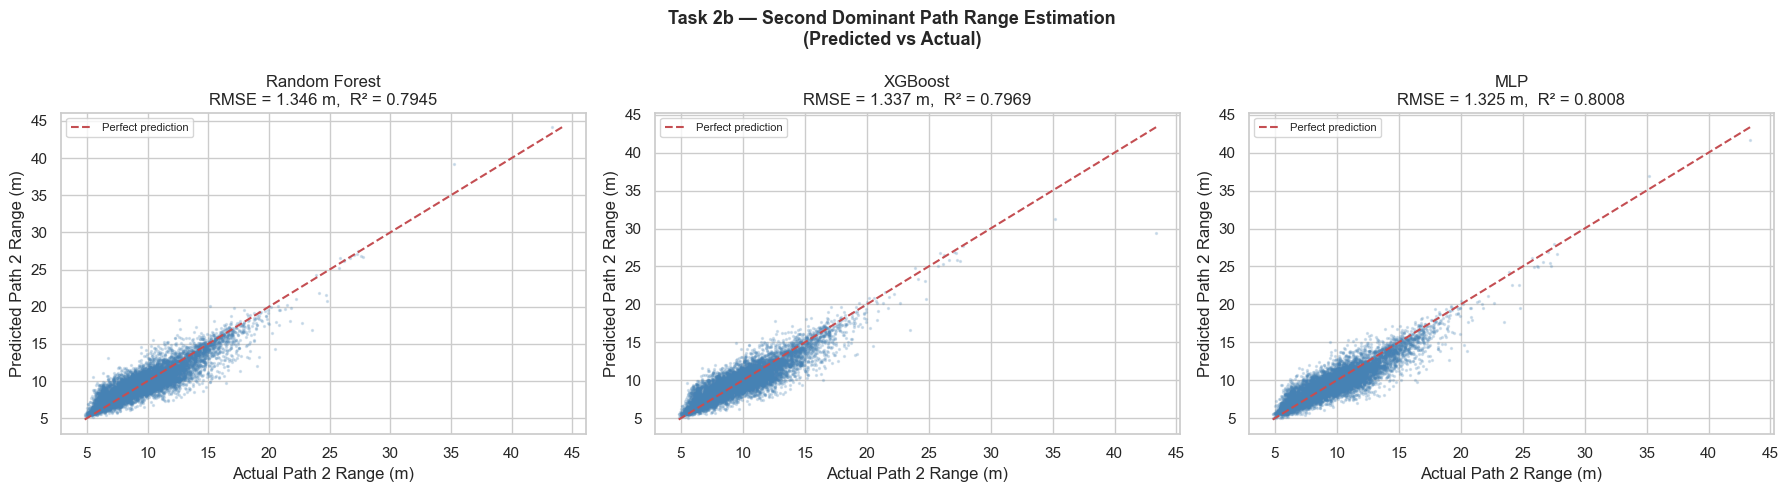

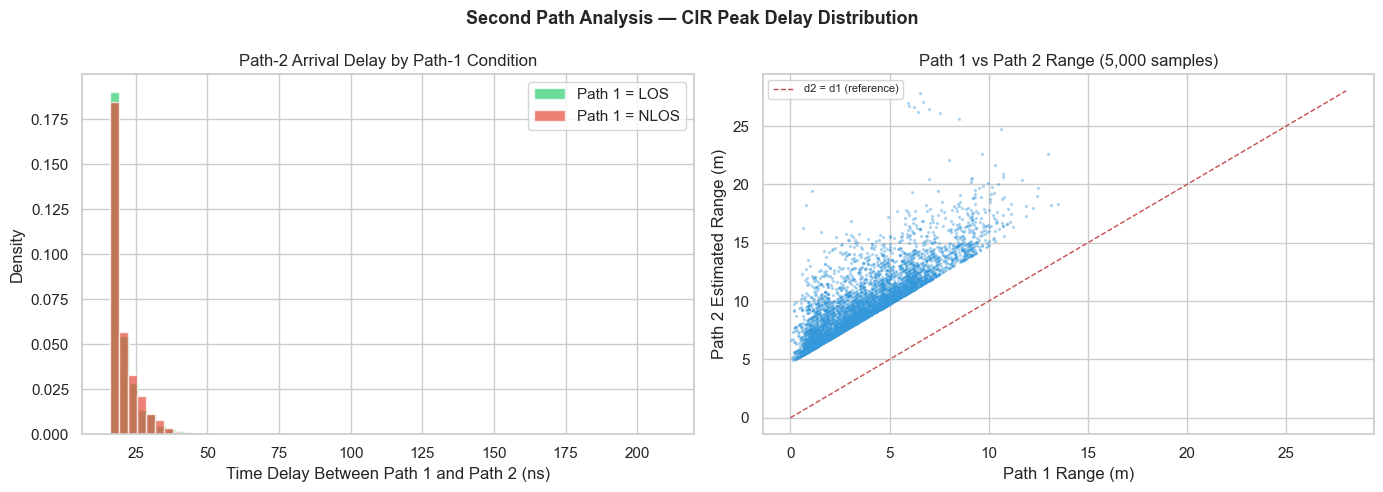


COMPLETE TWO-PATH SYSTEM — FINAL SUMMARY

INPUT: One CIR measurement (anchor-tag link)
  |
  |── PATH 1 (Shortest / First Detected)
  |      Classification  -> XGBoost / RF / CNN
  |                         LOS (0) or NLOS (1)
  |      Range Estimate  -> XGBoost Regressor
  |                         Predict RANGE from signal features
  |
  |── PATH 2 (Second Dominant)
         Classification  -> Always NLOS (by definition — no model needed)
         Range Estimate  -> Task 2b models (RF / XGBoost / MLP)
                           Predict d2 = d1 + delta_t * c

LOCALISATION DECISION:
  - If Path 1 = LOS  -> use measured RANGE directly (reliable)
  - If Path 1 = NLOS -> use Path 1 regressor's corrected range
  - Path 2 range used as secondary constraint for multilateration

Task 2b Regression Results:
                 RMSE     MAE      R²
MLP            1.3246  1.0128  0.8008
XGBoost        1.3375  1.0170  0.7969
Random Forest  1.3456  1.0168  0.7945

Task 2  Regression Results (Path 1,

In [36]:
# ── Visualisation: Predicted vs Actual for each Path-2 model ─────────────────
fig, axes = plt.subplots(1, len(path2_preds), figsize=(6 * len(path2_preds), 5))
if len(path2_preds) == 1:
    axes = [axes]
fig.suptitle("Task 2b — Second Dominant Path Range Estimation\n(Predicted vs Actual)", fontsize=13, fontweight='bold')

for ax, (name, y_pred) in zip(axes, path2_preds.items()):
    rmse = path2_reg_results[name]['RMSE']
    r2   = path2_reg_results[name]['R²']
    ax.scatter(y_p2_test, y_pred, alpha=0.2, s=2, color='steelblue', rasterized=True)
    lims = [min(y_p2_test.min(), y_pred.min()), max(y_p2_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel("Actual Path 2 Range (m)")
    ax.set_ylabel("Predicted Path 2 Range (m)")
    ax.set_title(f"{name}\nRMSE = {rmse:.3f} m,  R² = {r2:.4f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("path2_predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Visualisation: Delta index distribution (LOS vs NLOS first path) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Second Path Analysis — CIR Peak Delay Distribution", fontsize=13, fontweight='bold')

# Histogram of delta_ns split by NLOS label of the measurement
los_mask  = df_raw['NLOS'].values == 0
nlos_mask = df_raw['NLOS'].values == 1

axes[0].hist(delta_ns[los_mask],  bins=60, alpha=0.7, color='#2ecc71', label='Path 1 = LOS',  density=True)
axes[0].hist(delta_ns[nlos_mask], bins=60, alpha=0.7, color='#e74c3c', label='Path 1 = NLOS', density=True)
axes[0].set_xlabel("Time Delay Between Path 1 and Path 2 (ns)")
axes[0].set_ylabel("Density")
axes[0].set_title("Path-2 Arrival Delay by Path-1 Condition")
axes[0].legend()

# Scatter: Path-1 range vs Path-2 estimated range
sample_idx = np.random.choice(len(y_path2), size=5000, replace=False)
axes[1].scatter(df_raw['RANGE'].values[sample_idx], y_path2[sample_idx],
                alpha=0.3, s=2, color='#3498db')
axes[1].set_xlabel("Path 1 Range (m)")
axes[1].set_ylabel("Path 2 Estimated Range (m)")
axes[1].set_title("Path 1 vs Path 2 Range (5,000 samples)")
diag = [df_raw['RANGE'].min(), df_raw['RANGE'].max()]
axes[1].plot(diag, diag, 'r--', lw=1, label='d2 = d1 (reference)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("path2_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Full two-path pipeline summary ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("COMPLETE TWO-PATH SYSTEM — FINAL SUMMARY")
print("=" * 70)

print("""
INPUT: One CIR measurement (anchor-tag link)
  |
  |── PATH 1 (Shortest / First Detected)
  |      Classification  -> XGBoost / RF / CNN
  |                         LOS (0) or NLOS (1)
  |      Range Estimate  -> XGBoost Regressor
  |                         Predict RANGE from signal features
  |
  |── PATH 2 (Second Dominant)
         Classification  -> Always NLOS (by definition — no model needed)
         Range Estimate  -> Task 2b models (RF / XGBoost / MLP)
                           Predict d2 = d1 + delta_t * c

LOCALISATION DECISION:
  - If Path 1 = LOS  -> use measured RANGE directly (reliable)
  - If Path 1 = NLOS -> use Path 1 regressor's corrected range
  - Path 2 range used as secondary constraint for multilateration
""")

print("Task 2b Regression Results:")
print(pd.DataFrame(path2_reg_results).T.round(4).sort_values('RMSE').to_string())

print("\nTask 2  Regression Results (Path 1, for comparison):")
print(pd.DataFrame(reg_results).T.round(4).sort_values('RMSE').to_string())
